# AccuPrompt — Formulation Selector Simulation

This notebook simulates the **multi-armed bandit** that AccuPrompt uses to choose
*which* of the four accuracy-prompt formulations to show. It exercises the **same
epsilon-greedy policy** implemented in the extension (`src/content/selector.ts`),
ported to Python in `bandit.py`.

## What this demonstrates and what it does not

**Demonstrates:** that the implemented bandit, run over many interactions, learns
to favour the formulation with the higher *reflective-outcome rate* (where the user
reconsiders or cancels rather than sharing immediately), and accrues less **regret**
than uniform (equal-exposure) selection.

> **Important honesty note.** The per-formulation "true reflective rates" used below
> are **assumed, illustrative values**, not empirical findings. They let us test the
> *algorithm*. They do **not** claim any formulation is actually more effective for
> real users those rates would come from the cognitive walk-throughs or a deployed
> study. The simulation validates the *selector*, not the formulations.

This is a simple, **non-contextual** bandit on four arms with a proxy reward. The
contextual extension (personalising by user/context) is future work.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from bandit import EpsilonGreedyBandit, UniformSelector, FORMULATIONS, EPSILON

print("Formulations (arms):", FORMULATIONS)
print("Exploration rate epsilon:", EPSILON)


Formulations (arms): ['evaluation', 'importance', 'tips', 'normative']
Exploration rate epsilon: 0.25


## Assumed environment

Each synthetic user, when shown a formulation, produces a *reflective* outcome
(reward = 1) with the assumed probability below, else an immediate share (reward = 0).


In [ ]:
# ASSUMED true reflective rates(ILLUSTRATIVE not findings).
TRUE_RATES = {
    "evaluation": 0.55,
    "importance": 0.42,
    "tips":       0.48,
    "normative":  0.38,
}
BEST_ARM  = max(TRUE_RATES, key=TRUE_RATES.get)
BEST_RATE = TRUE_RATES[BEST_ARM]
print("Assumed best arm:", BEST_ARM, "@", BEST_RATE)


Assumed best arm: evaluation @ 0.55


## The policy under test

`EpsilonGreedyBandit.select()` is identical in logic to the extension's selector:
try any unseen arm first; with probability epsilon explore at random; otherwise
exploit the arm with the best observed mean reward.


In [3]:
import inspect
print(inspect.getsource(EpsilonGreedyBandit.select))


    def select(self) -> str:
        # 1) try any never-shown arm first
        unseen = [f for f, a in self.arms.items() if a.shown == 0]
        if unseen:
            return self.rng.choice(unseen)
        # 2) explore
        if self.rng.random() < self.epsilon:
            return self.rng.choice(FORMULATIONS)
        # 3) exploit: best mean reward
        return max(FORMULATIONS, key=lambda f: self.arms[f].rate)



## Run the simulation

We average over many independent runs to get smooth, representative curves, then
compare the bandit against uniform selection.


In [4]:
def simulate(make_selector, n_steps, seed):
    rng_py = random.Random(seed)
    rng_np = np.random.default_rng(seed)
    sel = make_selector(rng_py)
    cum_regret = np.zeros(n_steps)
    choices = []
    running = 0.0
    for t in range(n_steps):
        arm = sel.select()
        reward = 1.0 if rng_np.random() < TRUE_RATES[arm] else 0.0
        sel.update(arm, reward)
        running += (BEST_RATE - TRUE_RATES[arm])
        cum_regret[t] = running
        choices.append(arm)
    return cum_regret, choices

def avg_runs(make_selector, n_steps, n_runs):
    regrets = np.zeros((n_runs, n_steps))
    share = {f: np.zeros(n_steps) for f in FORMULATIONS}
    for r in range(n_runs):
        regret, choices = simulate(make_selector, n_steps, seed=1000 + r)
        regrets[r] = regret
        counts = {f: 0 for f in FORMULATIONS}
        for t, a in enumerate(choices):
            counts[a] += 1
            for f in FORMULATIONS:
                share[f][t] += counts[f] / (t + 1)
    return regrets.mean(axis=0), {f: share[f] / n_runs for f in FORMULATIONS}

N_STEPS, N_RUNS = 600, 200
b_regret, b_share = avg_runs(lambda rng: EpsilonGreedyBandit(rng=rng), N_STEPS, N_RUNS)
u_regret, _       = avg_runs(lambda rng: UniformSelector(rng=rng), N_STEPS, N_RUNS)
print("Final regret  — bandit: %.1f | uniform: %.1f" % (b_regret[-1], u_regret[-1]))
print("Final selection share (bandit):",
      {f: round(float(b_share[f][-1]), 3) for f in FORMULATIONS})


Final regret  — bandit: 23.8 | uniform: 55.5
Final selection share (bandit): {'evaluation': 0.634, 'importance': 0.1, 'tips': 0.186, 'normative': 0.08}


### Result 1 — Cumulative regret

Regret is how much expected reward we lost versus always picking the best arm.
Uniform selection never learns, so its regret grows **linearly**. The bandit's
regret grows **sub-linearly** as it concentrates on the better arm.


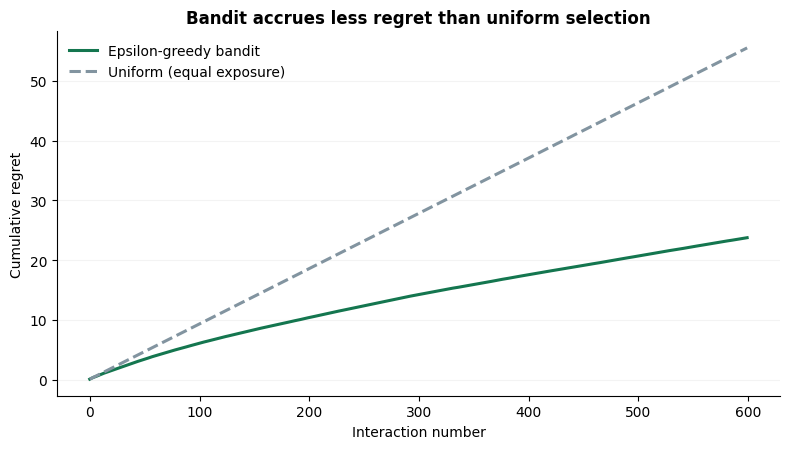

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(b_regret, color="#14764f", lw=2.2, label="Epsilon-greedy bandit")
ax.plot(u_regret, color="#8294a0", lw=2.2, ls="--", label="Uniform (equal exposure)")
ax.set_xlabel("Interaction number"); ax.set_ylabel("Cumulative regret")
ax.set_title("Bandit accrues less regret than uniform selection", fontweight="bold")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15); plt.tight_layout(); plt.show()


### Result 2 — Selection share over time

All arms start near 25% (the exploration phase). As evidence accumulates, the
bandit shifts selection toward the best arm while still exploring the rest.


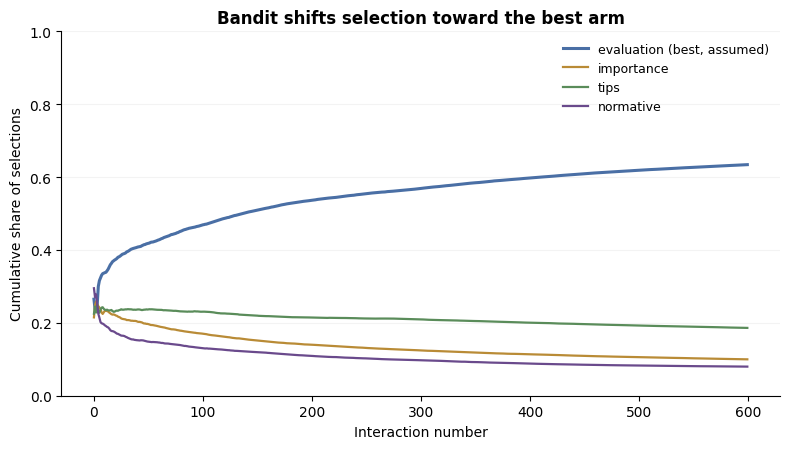

In [6]:
colors = ["#4A6FA5", "#B98B36", "#5A8C5A", "#6A4A8C"]
fig, ax = plt.subplots(figsize=(8, 4.6))
for i, f in enumerate(FORMULATIONS):
    lbl = f + (" (best, assumed)" if f == BEST_ARM else "")
    ax.plot(b_share[f], color=colors[i], lw=2.2 if f == BEST_ARM else 1.6, label=lbl)
ax.set_xlabel("Interaction number"); ax.set_ylabel("Cumulative share of selections")
ax.set_title("Bandit shifts selection toward the best arm", fontweight="bold")
ax.legend(frameon=False, fontsize=9); ax.set_ylim(0, 1)
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.15)
plt.tight_layout(); plt.show()


### Result 3 — Learned estimates vs assumed rates

After enough interactions, the bandit's estimated reflective rate per arm
approaches the assumed true rate — i.e. it is estimating the environment correctly.


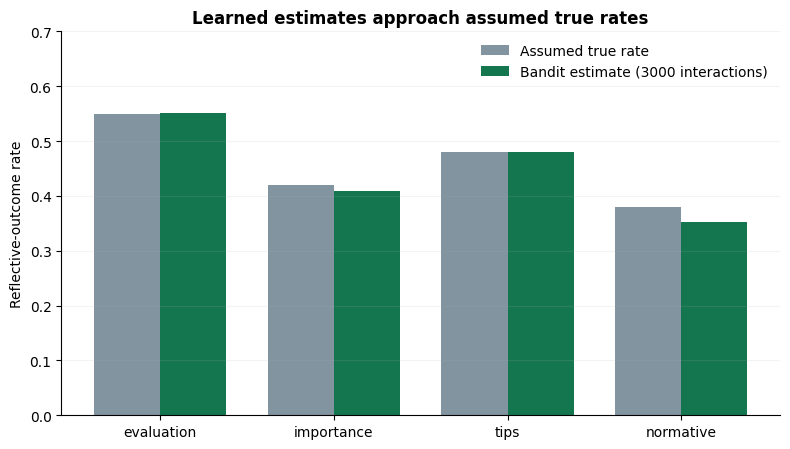

In [7]:
sel = EpsilonGreedyBandit(rng=random.Random(7))
rng_np = np.random.default_rng(7)
for _ in range(3000):
    a = sel.select()
    sel.update(a, 1.0 if rng_np.random() < TRUE_RATES[a] else 0.0)

est  = [sel.arms[f].rate for f in FORMULATIONS]
true = [TRUE_RATES[f] for f in FORMULATIONS]
x = np.arange(len(FORMULATIONS)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.bar(x - w/2, true, w, label="Assumed true rate", color="#8294a0")
ax.bar(x + w/2, est,  w, label="Bandit estimate (3000 interactions)", color="#14764f")
ax.set_xticks(x); ax.set_xticklabels(FORMULATIONS)
ax.set_ylabel("Reflective-outcome rate")
ax.set_title("Learned estimates approach assumed true rates", fontweight="bold")
ax.legend(frameon=False); ax.set_ylim(0, 0.7)
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.15)
plt.tight_layout(); plt.show()


## Summary

- The implemented epsilon-greedy bandit **learns**: it concentrates selection on the
  higher-reflective-rate formulation and incurs **sub-linear regret**, beating
  uniform selection.
- During the **actual walk-through study**, the extension runs the selector in
  **uniform mode** (equal exposure) so the qualitative comparison stays clean — the
  adaptive behaviour shown here is for use **outside** the controlled study.
- The reflective rates here are **assumed**; the simulation validates the *algorithm*,
  not the formulations. Real rates require the walk-throughs / a deployed study.
- Next step (future work): a **contextual** bandit that personalises the choice by
  user and message context.
